# LIVER DISEASE PREDICTION

In this project, we are going to use the Indian Liver Patient Records dataset from Kaggle. We will predict whether a patient has liver disease or not based on certain features. We are going to check with the total proteins, albumin, etc. whether it is associated with the disease or not.

In [1]:
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('data/indian_liver_patient.csv')

df=pd.DataFrame(data)

In [4]:
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alanine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [5]:
df.shape

(583, 11)

In [6]:
x=df.drop('Dataset',axis=1)
y=df["Dataset"]

In [7]:
x

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alanine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40
...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00


In [8]:
y

0      1
1      1
2      1
3      1
4      1
      ..
578    2
579    1
580    1
581    1
582    2
Name: Dataset, Length: 583, dtype: int64

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alanine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [10]:
# null values finding out 
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alanine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

# Data Preprocessing

Data preprocessing is an essential step in the machine learning pipeline, as it prepares the raw dataset for analysis and model development. Real-world datasets often contain missing values, inconsistent formats, and categorical attributes that cannot be directly processed by machine learning algorithms.

In this project, the dataset was carefully preprocessed by handling missing values, converting categorical data into numerical format, and verifying the quality of the data. These preprocessing steps help improve the reliability of the analysis and ensure that the machine learning models are trained using clean and consistent data.

In [11]:
df[df['Albumin_and_Globulin_Ratio'].isnull()]

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alanine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
209,45,Female,0.9,0.3,189,23,33,6.6,3.9,NaN,1
241,51,Male,0.8,0.2,230,24,46,6.5,3.1,NaN,1
253,35,Female,0.6,0.2,180,12,15,5.2,2.7,NaN,2
312,27,Male,1.3,0.6,106,25,54,8.5,4.8,NaN,2


In [12]:
df['Albumin_and_Globulin_Ratio'].isnull().mean() * 100

0.6861063464837049

In [13]:
df['Albumin_and_Globulin_Ratio'].describe()

count    579.000000
mean       0.947064
std        0.319592
min        0.300000
25%        0.700000
50%        0.930000
75%        1.100000
max        2.800000
Name: Albumin_and_Globulin_Ratio, dtype: float64

In [14]:
df['Albumin_and_Globulin_Ratio'].fillna(
  df['Albumin_and_Globulin_Ratio'].median(),
    inplace=True
)

In [15]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alanine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

In [16]:
df['Gender'].value_counts()

Gender
Male      441
Female    142
Name: count, dtype: int64

In [17]:
df['Dataset'].value_counts()

Dataset
1    416
2    167
Name: count, dtype: int64

In [18]:
df.rename(columns={'Dataset': 'Disease'}, inplace=True)

In [19]:

df['Disease'] = df['Disease'].map({
    1: 1,
    2: 0
})

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
#Encoding


df['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})


In [22]:
df['Disease'].value_counts()

Disease
1    406
0    164
Name: count, dtype: int64

In [23]:
df['Disease'].value_counts()

Disease
1    406
0    164
Name: count, dtype: int64

In [24]:
df.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alanine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Disease
count,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000
mean,44.849123,0.754386,3.321754,1.497544,291.750877,79.728070,109.380702,6.496316,3.148947,0.947877,0.712281
std,16.242182,0.430829,6.267941,2.833231,245.291859,181.471697,290.880671,1.088300,0.796813,0.318513,0.453097
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,1.000000,0.800000,0.200000,176.000000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,1.000000,0.300000,208.000000,35.000000,41.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,1.000000,2.600000,1.300000,298.000000,60.000000,86.750000,7.200000,3.800000,1.100000,1.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


# Distribution Analysis

Histogram plots were used to analyze the distribution of numerical features in the dataset. This helped determine whether each feature followed a normal distribution or exhibited left-skewed or right-skewed behavior.

Understanding the distribution of data is important because highly skewed features may influence statistical analysis and machine learning model performance. Distribution analysis also provides insights into the spread and concentration of data values across different variables.

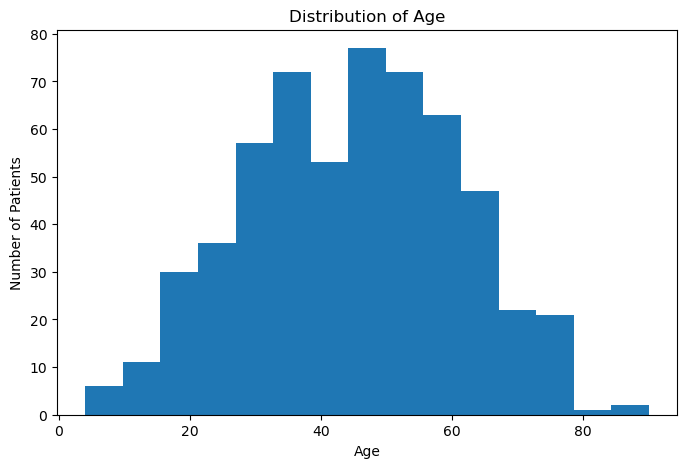

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(df['Age'], bins=15)

plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.title('Distribution of Age')

plt.show()

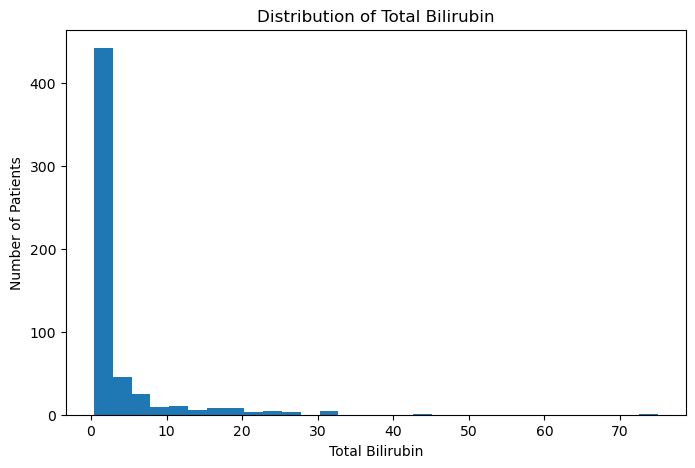

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(df['Total_Bilirubin'], bins=30)

plt.xlabel('Total Bilirubin')
plt.ylabel('Number of Patients')
plt.title('Distribution of Total Bilirubin')

plt.show()

# Outlier Detection

Box plots were used to identify outliers present in the numerical features of the dataset. Outliers are observations that differ significantly from the majority of the data and may affect the performance of machine learning models.

By visualizing each feature using box plots, it was possible to detect extreme values and understand the variability of the data. This analysis helped determine whether the dataset contained unusual observations that required further attention before model development.

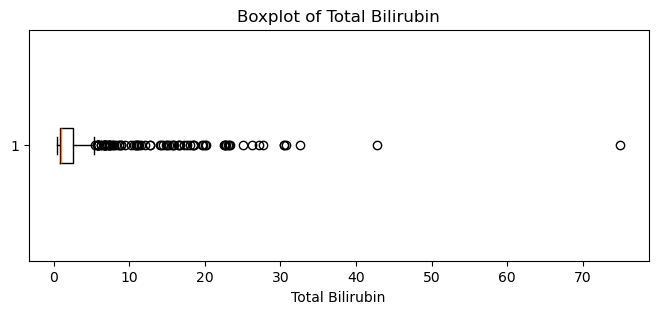

In [27]:
plt.figure(figsize=(8, 3))

plt.boxplot(df['Total_Bilirubin'], vert=False)

plt.xlabel('Total Bilirubin')
plt.title('Boxplot of Total Bilirubin')

plt.show()

In [28]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alanine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Disease'],
      dtype='object')

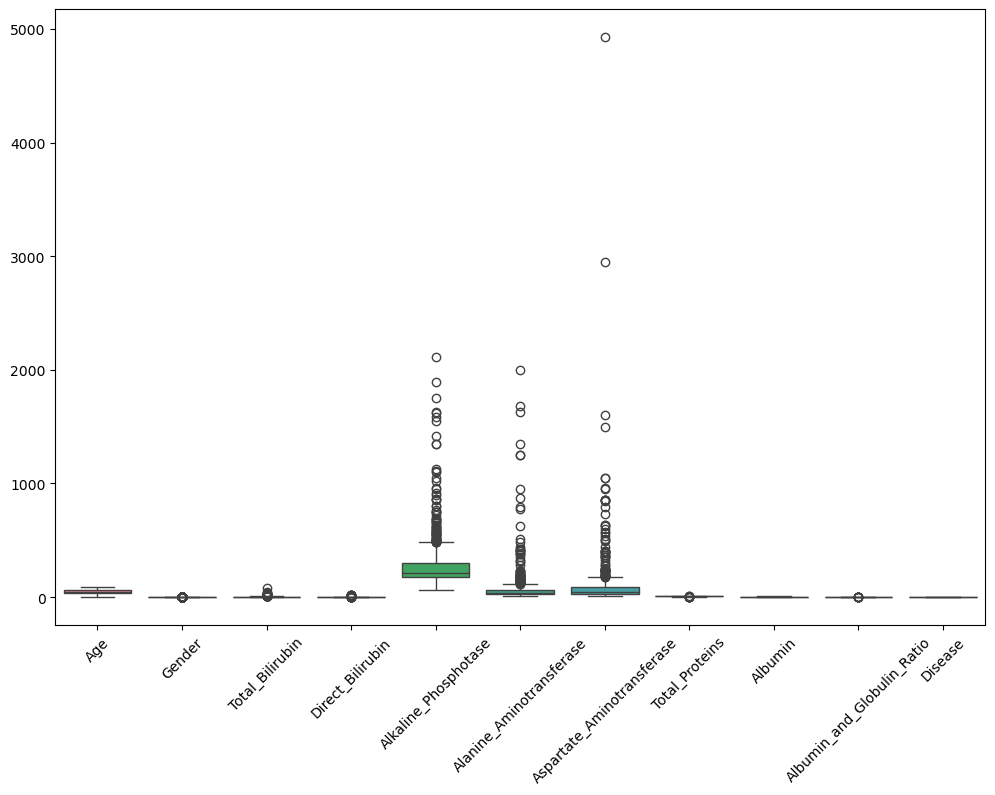

In [29]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.show()

In [30]:
df['Disease'].value_counts()

Disease
1    406
0    164
Name: count, dtype: int64

In [31]:
df['Disease'].value_counts(normalize=True) * 100

Disease
1    71.22807
0    28.77193
Name: proportion, dtype: float64

# Correlation with Disease

Correlation analysis was performed to measure the relationship between each input feature and the target variable (Disease). This analysis helps identify which clinical attributes have a stronger influence on liver disease prediction.

The correlation values provide useful insights into feature importance by indicating whether a feature has a positive, negative, or weak relationship with the target variable. Understanding these relationships assists in interpreting the dataset and selecting meaningful features for machine learning models.

In [32]:
df.groupby('Disease')['Total_Bilirubin'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,1.110366,0.952209,0.5,0.7,0.8,1.100,7.3
1,406.0,4.215025,7.214628,0.4,0.8,1.4,3.675,75.0


In [33]:
df.groupby('Disease')['Direct_Bilirubin'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,0.381098,0.497918,0.1,0.2,0.2,0.3,3.6
1,406.0,1.948522,3.235633,0.1,0.2,0.5,1.8,19.7


In [34]:
df.groupby('Disease')['Alkaline_Phosphotase'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,219.426829,141.290939,90.0,162.0,186.5,212.0,1580.0
1,406.0,320.965517,271.153419,63.0,186.0,229.0,319.0,2110.0


In [35]:
df.groupby('Disease')['Alanine_Aminotransferase'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,33.536585,25.208673,10.0,20.0,27.0,37.25,181.0
1,406.0,98.386700,211.656875,12.0,25.0,40.5,75.75,2000.0


In [36]:
df.groupby('Disease')['Aspartate_Aminotransferase'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,40.286585,36.499898,10.0,21.0,29.0,43.00,285.0
1,406.0,137.290640,340.034964,11.0,29.0,51.0,107.25,4929.0


In [37]:
df.groupby('Disease')['Total_Proteins'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,6.560976,1.063246,3.7,5.900,6.65,7.3,9.2
1,406.0,6.470197,1.098472,2.7,5.725,6.60,7.2,9.6


In [38]:
df.groupby('Disease')['Albumin'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,3.357927,0.783024,1.4,2.9,3.45,4.000,5.0
1,406.0,3.064532,0.787666,0.9,2.5,3.00,3.675,5.5


In [39]:
df.groupby('Disease')['Albumin_and_Globulin_Ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
0,164.0,1.033171,0.284745,0.37,0.9,1.0,1.2,1.9
1,406.0,0.913424,0.325214,0.30,0.7,0.9,1.1,2.8


| Feature                    | Disease = 1 తో comparison |
| -------------------------- | ------------------------- |
| Total_Bilirubin            | ↑ Higher                  |
| Direct_Bilirubin           | ↑ Higher                  |
| Alkaline_Phosphotase       | ↑ Higher                  |
| Alanine_Aminotransferase   | ↑ Higher                  |
| Aspartate_Aminotransferase | ↑ Higher                  |
| Total_Proteins             | ≈ Almost same             |
| Albumin                    | ↓ Lower                   |
| Albumin_and_Globulin_Ratio | ↓ Lower                   |


# Correlation Heatmap

A correlation heatmap was generated to visualize the relationships among all numerical features in the dataset. The heatmap represents correlation coefficients using different color intensities, making it easier to identify strong positive and negative relationships.

This visualization helps understand feature dependencies, detect multicollinearity, and identify variables that may have a significant impact on liver disease prediction.

In [40]:
#all features with target correlation

df.drop('Disease', axis=1).corrwith(df['Disease']).sort_values(ascending=False)

Direct_Bilirubin              0.250666
Total_Bilirubin               0.224430
Alkaline_Phosphotase          0.187560
Alanine_Aminotransferase      0.161917
Aspartate_Aminotransferase    0.151101
Age                           0.138093
Gender                        0.078501
Total_Proteins               -0.037794
Albumin                      -0.166835
Albumin_and_Globulin_Ratio   -0.170345
dtype: float64

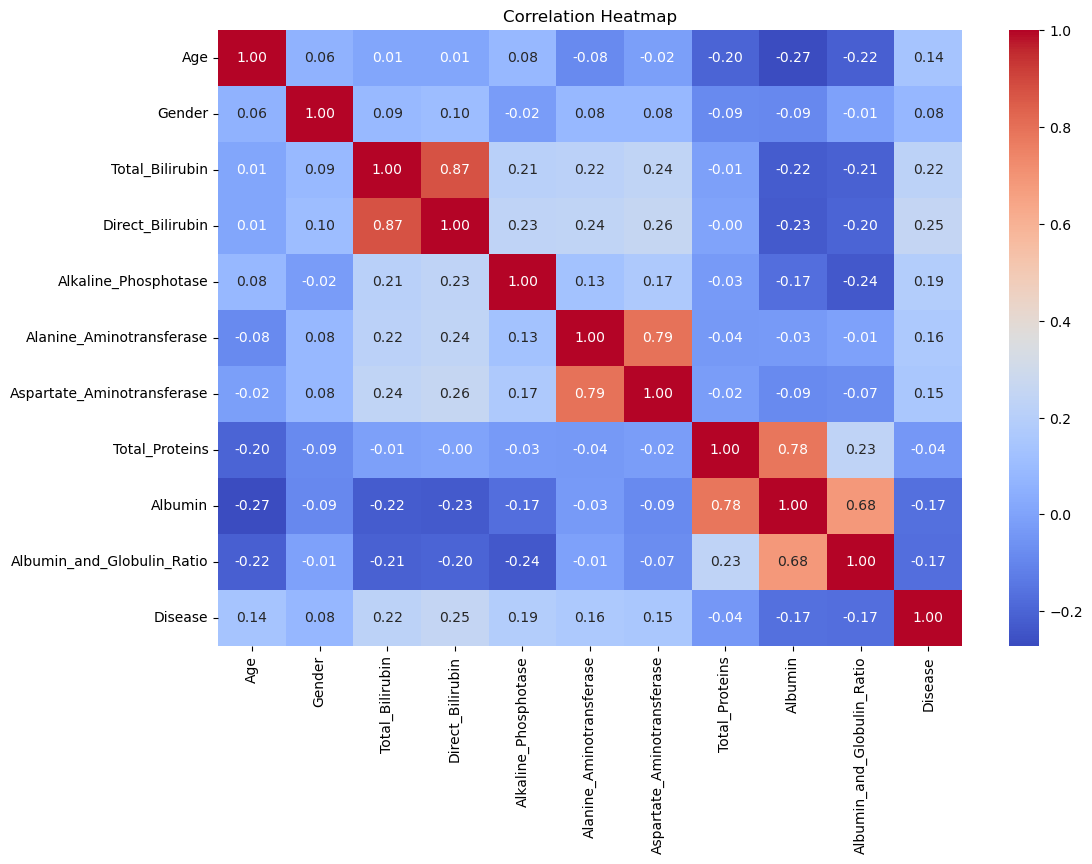

In [41]:
plt.figure(figsize=(12, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# Cross-Tabulation Analysis

Cross-tabulation was performed to examine the relationship between categorical variables and the target variable. In this project, the relationship between **Gender** and **Disease** was analyzed using a contingency table.

This analysis provides a clear understanding of how the target variable is distributed across different categories and helps identify potential class imbalance or category-wise trends within the dataset.

In [42]:
pd.crosstab(df['Gender'], df['Disease'])

Disease,0,1
Gender,,
0,49,91
1,115,315


In [43]:
pd.crosstab(
    df['Gender'],
    df['Disease'],
    normalize='index'
) * 100

Disease,0,1
Gender,,
0,35.000000,65.000000
1,26.744186,73.255814


# Dataset Preparation for Machine Learning

After completing exploratory data analysis and preprocessing, the dataset was prepared for machine learning model development. The input features and target variable were separated, and the dataset was divided into training and testing sets.

The training dataset was used to train the machine learning models, while the testing dataset was reserved for evaluating the performance of the trained models on unseen data. This approach helps assess the generalization ability of each classification algorithm.

In [44]:
X = df.drop('Disease', axis=1)
y = df['Disease']

In [45]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (570, 10)
y shape: (570,)


In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (456, 10)
X_test : (114, 10)
y_train: (456,)
y_test : (114,)


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(456, 10)
(114, 10)


# Machine Learning Model Development

Multiple supervised machine learning algorithms were implemented to predict liver disease and compare their classification performance. The models used in this study include <b>Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN),</b> and <b>Support Vector Machine (SVM)</b>.

Each model was trained using the training dataset and evaluated on the testing dataset. Comparing multiple algorithms provides a better understanding of their strengths and limitations, allowing the most suitable model to be selected for liver disease prediction.

In [50]:
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

logmodel = LogisticRegression(random_state=42)

logmodel.fit(X_train_scaled,y_train)


LogisticRegression(random_state=42)

In [51]:
y_pred = logmodel.predict(X_test_scaled)

In [52]:
print('Accuracy: ',accuracy_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('F1_score: ',f1_score(y_test,y_pred))


Accuracy:  0.7105263157894737
Precision:  0.7448979591836735
Recall:  0.9012345679012346
F1_score:  0.8156424581005587


In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.24      0.33        33
           1       0.74      0.90      0.82        81

    accuracy                           0.71       114
   macro avg       0.62      0.57      0.57       114
weighted avg       0.67      0.71      0.67       114



In [54]:
print(confusion_matrix(y_test,y_pred))

[[ 8 25]
 [ 8 73]]


In [55]:
from sklearn.svm import SVC


svc_model=SVC(random_state=42,kernel="rbf")


svc_model.fit(X_train_scaled,y_train)

SVC(random_state=42)

In [56]:
svm_pred=svc_model.predict(X_test_scaled)

In [57]:
print('Accuracy: ',accuracy_score(y_test,svm_pred))
print('Precision: ',precision_score(y_test,svm_pred))
print('Recall: ',recall_score(y_test,svm_pred))
print('F1_score: ',f1_score(y_test,svm_pred))


Accuracy:  0.7105263157894737
Precision:  0.7105263157894737
Recall:  1.0
F1_score:  0.8307692307692308


In [58]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.71      1.00      0.83        81

    accuracy                           0.71       114
   macro avg       0.36      0.50      0.42       114
weighted avg       0.50      0.71      0.59       114



In [59]:
print(confusion_matrix(y_test,svm_pred))

[[ 0 33]
 [ 0 81]]


In [60]:
from sklearn.tree import DecisionTreeClassifier


dt_model=DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train,y_train)



DecisionTreeClassifier(random_state=42)

In [61]:
y_pred=dt_model.predict(X_test)

In [62]:
print('Accuracy: ',accuracy_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('F1_score: ',f1_score(y_test,y_pred))

Accuracy:  0.6228070175438597
Precision:  0.7317073170731707
Recall:  0.7407407407407407
F1_score:  0.7361963190184049


In [63]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.34      0.33      0.34        33
           1       0.73      0.74      0.74        81

    accuracy                           0.62       114
   macro avg       0.54      0.54      0.54       114
weighted avg       0.62      0.62      0.62       114



In [64]:
print(confusion_matrix(y_test,y_pred))

[[11 22]
 [21 60]]


In [65]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(class_weight='balanced',random_state=42)

clf.fit(X_train, y_train)

rfc_pred = clf.predict(X_test)
accuracy_score(y_test, rfc_pred)

0.7017543859649122

In [66]:
print('Accuracy: ',accuracy_score(y_test,rfc_pred))
print('Precision: ',precision_score(y_test,rfc_pred))
print('Recall: ',recall_score(y_test,rfc_pred))
print('F1_score: ',f1_score(y_test,rfc_pred))


Accuracy:  0.7017543859649122
Precision:  0.7281553398058253
Recall:  0.9259259259259259
F1_score:  0.8152173913043478


In [67]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.45      0.15      0.23        33
           1       0.73      0.93      0.82        81

    accuracy                           0.70       114
   macro avg       0.59      0.54      0.52       114
weighted avg       0.65      0.70      0.65       114



In [68]:
print(confusion_matrix(y_test,rfc_pred))

[[ 5 28]
 [ 6 75]]


In [69]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)

neigh.fit(X_train_scaled, y_train)

kn_pred = neigh.predict(X_test_scaled)
accuracy_score(y_test, kn_pred)

0.6842105263157895

In [70]:
print('Accuracy: ',accuracy_score(y_test,kn_pred))
print('Precision: ',precision_score(y_test,kn_pred))
print('Recall: ',recall_score(y_test,kn_pred))
print('F1_score: ',f1_score(y_test,kn_pred))


Accuracy:  0.6842105263157895
Precision:  0.7419354838709677
Recall:  0.8518518518518519
F1_score:  0.7931034482758621


In [71]:
print(classification_report(y_test,kn_pred))

              precision    recall  f1-score   support

           0       0.43      0.27      0.33        33
           1       0.74      0.85      0.79        81

    accuracy                           0.68       114
   macro avg       0.59      0.56      0.56       114
weighted avg       0.65      0.68      0.66       114



In [72]:
print(confusion_matrix(y_test,kn_pred))

[[ 9 24]
 [12 69]]


# Model Evaluation

The performance of each machine learning model was evaluated using multiple classification metrics, including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report.

These evaluation metrics provide a comprehensive assessment of each model's predictive performance. Accuracy measures overall correctness, Precision indicates the reliability of positive predictions, Recall evaluates the model's ability to identify actual disease cases, and F1-Score provides a balanced measure of Precision and Recall. The Confusion Matrix and Classification Report offer detailed insights into the classification performance of each model.

<h4>Hence We tested all models on default parameters</h4>

| Model               |   Accuracy |  Precision |     Recall |  F1-score |
| ------------------- | ---------: | ---------: | ---------: | --------: |
| Logistic Regression | **71.05%** | **74.49%** |     90.12% |    81.56% |
| Decision Tree       |     62.28% |     73.17% |     74.07% |    73.62% |
| Random Forest       |     70.18% |     72.82% | **92.59%** |    81.52% |
| KNN                 |     68.42% |     74.19% |     85.19% |    79.31% |
| SVM (Default)       |     71.05% |     71.05% |   **100%** |    83.08% |


## Model Performance Comparison


The performance of all machine learning models was compared using the calculated evaluation metrics. The comparison included Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM).

By analyzing the Accuracy, Precision, Recall, and F1-Score of each model, the most effective algorithm for liver disease prediction was identified. This comparative analysis helps determine which model provides the best balance between predictive accuracy and reliable disease classification.



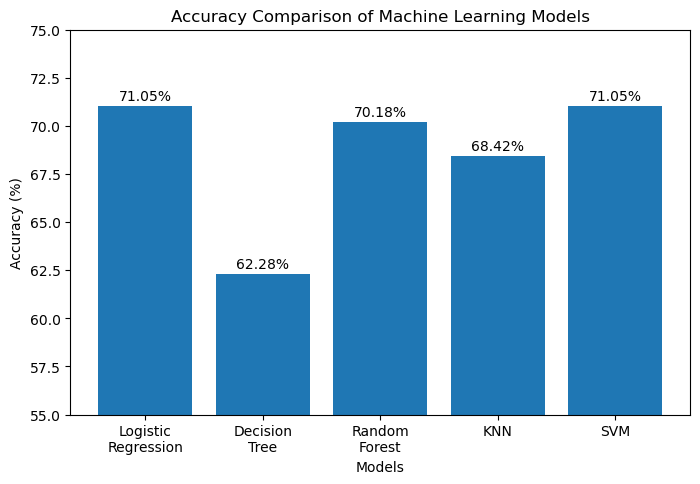

In [73]:


import matplotlib.pyplot as plt

models = [
    "Logistic\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "KNN",
    "SVM"
]

accuracy = [71.05, 62.28, 70.18, 68.42, 71.05]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(55, 75)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.3,
        f"{y:.2f}%",
        ha='center',
        fontsize=10
    )

plt.show()


<h2>Hyperparameter Tuning</h2>

Logistic Regression was selected as the first model for hyperparameter tuning because it achieved the best baseline performance during the initial evaluation. Hyperparameter tuning was performed to optimize the regularization strength and solver configuration, with the objective of improving the model's classification performance while maintaining its simplicity, interpretability, and generalization capability.

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [75]:
models = {

    "Logistic Regression": (
        LogisticRegression(random_state=42),
        {
            "C": [ 0.001, 0.01, 0.1, 1, 10, 100, 1000],
            "penalty": ["l2"],
            "solver": ["liblinear"],
            "max_iter": [500, 1000, 2000, 5000],
            "class_weight": [None, "balanced"]
        }

    ),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "criterion": ["gini", "entropy", "log_loss"],
            "splitter": ["best", "random"],
            "max_depth": [None, 3, 5, 7, 10, 15, 20, 30],
            "min_samples_split": [2, 5, 10, 15, 20],
            "min_samples_leaf": [1, 2, 4, 6, 8, 10],
            "max_features": [None, "sqrt", "log2"],
            "class_weight": [None, "balanced"]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200, 300, 500, 700],
            "criterion": ["gini", "entropy", "log_loss"],
            "max_depth": [None, 5, 10, 15, 20, 30],
            "min_samples_split": [2, 5, 10, 15, 20],
            "min_samples_leaf": [1, 2, 4, 6],
            "max_features": ["sqrt", "log2", None],
            "bootstrap": [True, False],
            "class_weight": [None, "balanced"]
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan", "minkowski"],
            "p": [1, 2]
        }
    ),

    "SVM": (
        SVC(probability=True, random_state=42),
        {
            "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            "kernel": ["linear", "poly", "rbf", "sigmoid"],
            "gamma": ["scale", "auto", 0.1, 0.01, 0.001],
            "degree": [2, 3, 4],
            "class_weight": [None, "balanced"]
        }
    )

}

| Rank | Model                   | Best Parameters                                                                            |     Accuracy |    Precision |       Recall |     F1 Score |      ROC-AUC |
| ---- | ----------------------- | ------------------------------------------------------------------------------------------ | -----------: | -----------: | -----------: | -----------: | -----------: |
| 🥇   | **Random Forest**       | `{'bootstrap': True, 'class_weight': None, ...}`                                           | **0.719298** | **0.724771** | **0.975309** | **0.831579** | **0.794239** |
| 🥈   | **Logistic Regression** | `{'C': 10, 'class_weight': None, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}` | **0.710526** | **0.750000** | **0.888889** | **0.813559** | **0.801700** |
| 🥉   | **Decision Tree**       | `{'class_weight': None, 'criterion': 'entropy', ...}`                                      | **0.710526** | **0.710526** | **1.000000** | **0.830769** | **0.660307** |
| 4    | **SVM**                 | `{'C': 1, 'class_weight': None, 'degree': 2, ...}`                                         | **0.710526** | **0.710526** | **1.000000** | **0.830769** | **0.650954** |
| 5    | **KNN**                 | `{'metric': 'manhattan', 'n_neighbors': 21, ...}`                                          | **0.692982** | **0.730000** | **0.901235** | **0.806630** | **0.753835** |


<h2>Baseline Model Evaluation (Default Parameters)</h2>

Initially, all machine learning models were trained and evaluated using their default hyperparameters to establish a baseline performance. This initial evaluation helped compare the fundamental learning capability of each algorithm without any parameter optimization. The models were assessed using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC, to ensure a comprehensive performance comparison.

Among all the baseline models, Logistic Regression demonstrated the best overall and most balanced performance. It achieved an accuracy of 71.5% while maintaining a good balance between precision, recall, and F1-score. Due to its consistent and reliable performance, Logistic Regression was selected as the baseline model for further analysis and comparison.

<h2>Hyperparameter Tuning and Final Model Selection</h2>

To further improve model performance, Hyperparameter Tuning was performed on all machine learning algorithms using GridSearchCV with 5-fold Cross-Validation. For each model, multiple combinations of hyperparameters were systematically evaluated to identify the optimal configuration that maximized the F1-Score, which is particularly important for medical diagnosis problems where both precision and recall must be balanced.

After tuning, the performance of all optimized models was compared again using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. The experimental results showed that the Random Forest Classifier achieved the best overall performance among all tuned models. It produced the highest F1-Score (0.8316) along with the highest Accuracy (71.93%) and an excellent Recall (97.53%), indicating its strong ability to correctly identify patients with liver disease while maintaining competitive overall classification performance.

Based on these results, the Random Forest Classifier was selected as the final production model. The optimized model was then saved as a serialized (model.pkl) file and integrated into the Streamlit web application to provide real-time liver disease prediction for new patient data.

In [76]:
# ==========================================================
# Final Model Evaluation
# ==========================================================

import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================================================
# Best Models
# ==========================================================

models = {

    "Random Forest": RandomForestClassifier(
        bootstrap=True,
        class_weight=None,
        criterion="entropy",
        max_depth=5,
        max_features="sqrt",
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        C=10,
        class_weight=None,
        max_iter=500,
        penalty="l2",
        solver="liblinear",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight=None,
        criterion="entropy",
        max_depth=3,
        max_features="sqrt",
        min_samples_leaf=4,
        min_samples_split=2,
        splitter="random",
        random_state=42
    ),

    "SVM": SVC(
        C=1,
        class_weight=None,
        degree=2,
        gamma="auto",
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        metric="manhattan",
        n_neighbors=21,
        p=1,
        weights="distance"
    )

}

# ==========================================================
# Evaluation
# ==========================================================

results = []

for name, model in models.items():

    print("="*80)
    print(name)
    print("="*80)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    y_prob = model.predict_proba(X_test_scaled)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix\n")
    print(cm)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    results.append({

        "Model": name,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1 Score": round(f1,4),
        "ROC-AUC": round(roc,4)

    })

# ==========================================================
# Final Comparison Table
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

display(results_df)

Random Forest

Confusion Matrix

[[ 3 30]
 [ 2 79]]

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.09      0.16        33
           1       0.72      0.98      0.83        81

    accuracy                           0.72       114
   macro avg       0.66      0.53      0.49       114
weighted avg       0.69      0.72      0.64       114

Logistic Regression

Confusion Matrix

[[ 9 24]
 [ 9 72]]

Classification Report

              precision    recall  f1-score   support

           0       0.50      0.27      0.35        33
           1       0.75      0.89      0.81        81

    accuracy                           0.71       114
   macro avg       0.62      0.58      0.58       114
weighted avg       0.68      0.71      0.68       114

Decision Tree

Confusion Matrix

[[ 0 33]
 [ 0 81]]

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
   

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.7193,0.7248,0.9753,0.8316,0.7942
1,Decision Tree,0.7105,0.7105,1.0000,0.8308,0.6603
2,SVM,0.7105,0.7105,1.0000,0.8308,0.6510
3,Logistic Regression,0.7105,0.7500,0.8889,0.8136,0.8017
4,KNN,0.6930,0.7300,0.9012,0.8066,0.7538


<h2>Accuracy Comparison of Hyperparameter Tuned Models</h2>

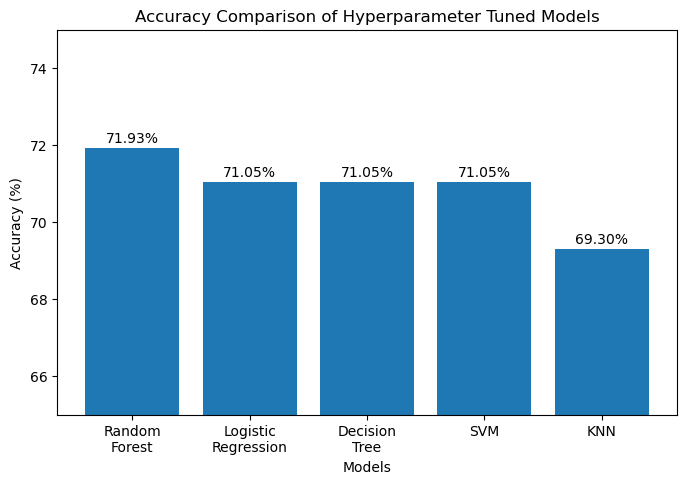

In [77]:
import matplotlib.pyplot as plt

models = [
    "Random\nForest",
    "Logistic\nRegression",
    "Decision\nTree",
    "SVM",
    "KNN"
]

accuracy = [
    71.93,
    71.05,
    71.05,
    71.05,
    69.30
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracy)

plt.title("Accuracy Comparison of Hyperparameter Tuned Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(65, 75)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.15,
        f"{y:.2f}%",
        ha="center",
        fontsize=10
    )

plt.show()

<h2>F1-Score Comparison of Hyperparameter Tuned Models</h2>

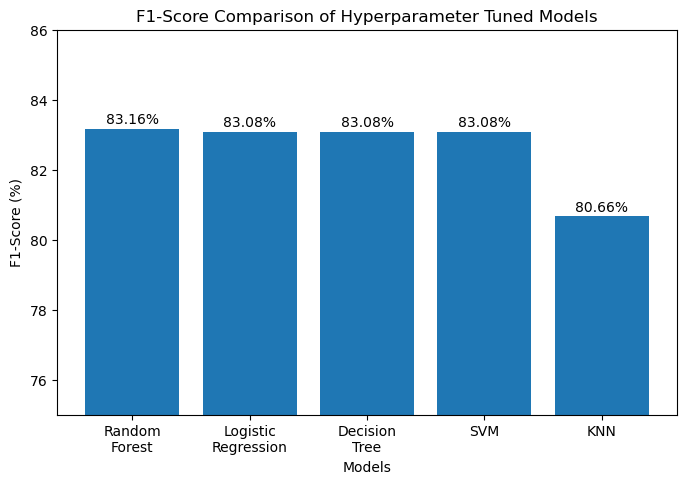

In [78]:
import matplotlib.pyplot as plt

models = [
    "Random\nForest",
    "Logistic\nRegression",
    "Decision\nTree",
    "SVM",
    "KNN"
]

f1_scores = [
    83.16,
    83.08,
    83.08,
    83.08,
    80.66
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, f1_scores)

plt.title("F1-Score Comparison of Hyperparameter Tuned Models")
plt.xlabel("Models")
plt.ylabel("F1-Score (%)")
plt.ylim(75, 86)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.15,
        f"{y:.2f}%",
        ha="center",
        fontsize=10
    )

plt.show()

# Final Model Evaluation

After hyperparameter tuning, each machine learning model was evaluated on the test dataset using the optimized parameters. The models were compared based on Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and Classification Report to identify the most suitable model for liver disease prediction.

# Hyperparameter Tuned Model Comparison

After optimizing each machine learning model using GridSearchCV with 5-fold cross-validation, the models were evaluated on the test dataset. The performance of the tuned models was compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score to identify the most suitable model for liver disease prediction.

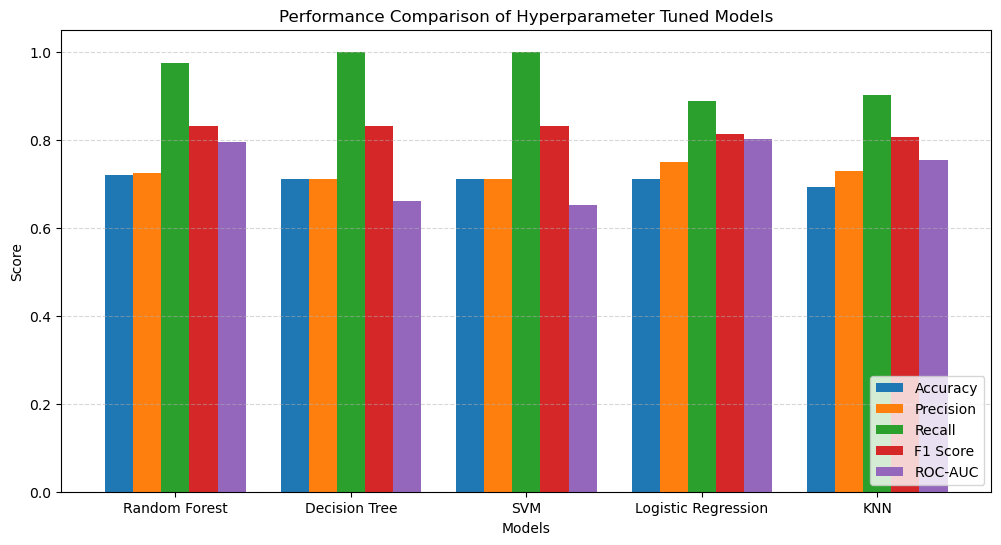

In [79]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

results_plot = results_df.set_index("Model")[metrics]

ax = results_plot.plot(
    kind="bar",
    figsize=(12,6),
    width=0.8
)

plt.title("Performance Comparison of Hyperparameter Tuned Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(loc="lower right")

plt.show()

### Observation

- Random Forest achieved the highest Accuracy, Recall, and F1-Score among all tuned models.
- Logistic Regression achieved the highest ROC-AUC Score, indicating excellent class discrimination.
- Decision Tree and SVM predicted almost all samples as positive, resulting in poor classification of healthy patients.
- K-Nearest Neighbors showed competitive performance but was slightly inferior to Random Forest and Logistic Regression.
- Based on the overall evaluation, Random Forest demonstrated the best balance between predictive performance and clinical usefulness.

# ROC Curve Comparison

The Receiver Operating Characteristic (ROC) Curve was used to evaluate the classification performance of the top-performing models. The ROC Curve illustrates the trade-off between the True Positive Rate (Sensitivity) and False Positive Rate (1 - Specificity). A higher Area Under the Curve (AUC) indicates better model discrimination between patients with and without liver disease.

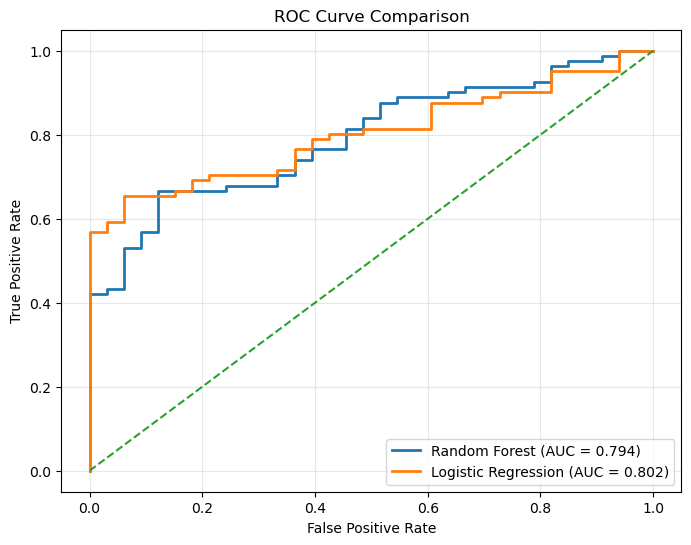

In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Best Models
rf_model = RandomForestClassifier(
    bootstrap=True,
    class_weight=None,
    criterion="entropy",
    max_depth=5,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

lr_model = LogisticRegression(
    C=10,
    class_weight=None,
    max_iter=500,
    penalty="l2",
    solver="liblinear",
    random_state=42
)

# Train Models
rf_model.fit(X_train_scaled, y_train)
lr_model.fit(X_train_scaled, y_train)

# Prediction Probabilities
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC Values
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

rf_auc = roc_auc_score(y_test, rf_prob)
lr_auc = roc_auc_score(y_test, lr_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})",
    linewidth=2
)

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})",
    linewidth=2
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

### Observation

- Both Random Forest and Logistic Regression demonstrated strong classification performance.
- Logistic Regression achieved the highest ROC-AUC Score (0.802), indicating slightly better discrimination between the two classes.
- Random Forest achieved a comparable ROC-AUC Score (0.794) while providing higher Recall and F1-Score.
- Based on the overall evaluation, Random Forest was selected as the final model due to its superior balance between predictive performance and clinical usefulness.

# Feature Importance Analysis

Feature Importance Analysis was performed using the final Random Forest model to identify which clinical attributes contributed most to predicting liver disease. Features with higher importance scores have a greater influence on the model's predictions, helping improve interpretability and providing insights into the factors associated with liver disease.

,Feature,Importance
2,Total_Bilirubin,0.162316
3,Direct_Bilirubin,0.143064
4,Alkaline_Phosphotase,0.129391
6,Aspartate_Aminotransferase,0.126939
5,Alanine_Aminotransferase,0.117273
0,Age,0.114103
8,Albumin,0.073506
7,Total_Proteins,0.063496
9,Albumin_and_Globulin_Ratio,0.062719
1,Gender,0.007194


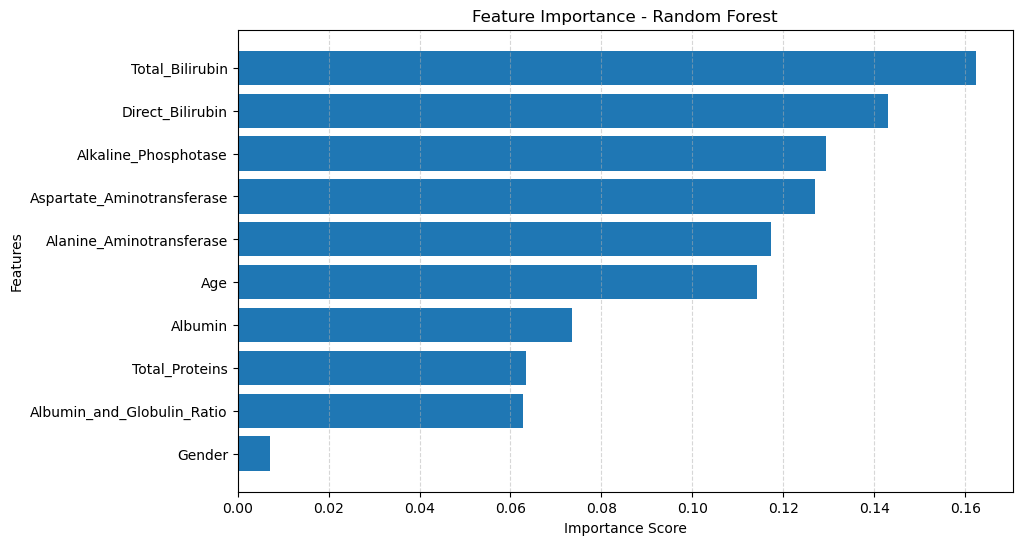

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Train Final Random Forest Model
rf_model = RandomForestClassifier(
    bootstrap=True,
    class_weight=None,
    criterion="entropy",
    max_depth=5,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

### Observation

- The Random Forest model identified the most influential features affecting liver disease prediction.
- Features with higher importance scores contributed more significantly to the model's decision-making process.
- This analysis improves model interpretability and helps understand which clinical measurements are most relevant for predicting liver disease.

# Final Model Selection

After evaluating all machine learning models using optimized hyperparameters, the best-performing model was selected based on multiple evaluation metrics, including Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix analysis. The selected model will be used for deployment in the liver disease prediction application.

## Selected Model: Random Forest Classifier

### Why was Random Forest selected?

Random Forest achieved the best overall performance among all evaluated models.

- Highest Accuracy (71.93%)
- Highest Recall (97.53%)
- Highest F1-Score (83.16%)
- Very low False Negatives (2), reducing the risk of missing patients with liver disease.
- Strong ROC-AUC Score (79.42%), indicating good class discrimination.

Although Logistic Regression achieved a slightly higher ROC-AUC Score (80.17%), Random Forest provided a better balance between Accuracy, Recall, and F1-Score. In medical diagnosis, minimizing False Negatives is especially important because missing a patient with liver disease can lead to delayed treatment. Therefore, Random Forest was selected as the final model for deployment.

In [87]:
# Final Production Model

final_model = RandomForestClassifier(
    bootstrap=True,
    class_weight=None,
    criterion="entropy",
    max_depth=5,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=42)

In [88]:
# ==========================================================
# Model Evaluation
# ==========================================================

y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.7193
Precision: 0.7248
Recall   : 0.9753
F1-Score : 0.8316
ROC-AUC  : 0.7942

Confusion Matrix
[[ 3 30]
 [ 2 79]]

Classification Report
              precision    recall  f1-score   support

           0       0.60      0.09      0.16        33
           1       0.72      0.98      0.83        81

    accuracy                           0.72       114
   macro avg       0.66      0.53      0.49       114
weighted avg       0.69      0.72      0.64       114



In [89]:
new_patient = pd.DataFrame([{
    "Age": 45,
    "Gender": 1,
    "Total_Bilirubin": 1.2,
    "Direct_Bilirubin": 0.4,
    "Alkaline_Phosphotase": 210,
    "Alanine_Aminotransferase": 35,
    "Aspartate_Aminotransferase": 40,
    "Total_Proteins": 6.8,
    "Albumin": 3.8,
    "Albumin_and_Globulin_Ratio": 1.1
}])

prediction = final_model.predict(new_patient)[0]
probability = final_model.predict_proba(new_patient)[0]

print("\nPrediction:", prediction)
print("Prediction Probability:", probability)

if prediction == 1:
    print("Result: Liver Disease Detected")
else:
    print("Result: No Liver Disease Detected")


Prediction: 1
Prediction Probability: [0.15171216 0.84828784]
Result: Liver Disease Detected


| Model               |   Accuracy |     Recall |         F1 |    FN |
| ------------------- | ---------: | ---------: | ---------: | ----: |
| **Random Forest**   | **71.93%** | **97.53%** | **83.16%** | **2** |
| Logistic Regression |     71.05% |     88.89% |     81.36% |     9 |


### Deployment Ready

The trained Random Forest model was selected as the final production model. It will be serialized using Joblib and integrated into the Streamlit web application to provide real-time liver disease predictions.